# Style factors — Barra-style model on sectors + styles

Extends the sector dummy model with **style factors**: continuous, cross-sectionally
standardized exposures in the spirit of Barra USE4. Same estimation idea, richer $X$:

$$r_t = X_t f_t + \varepsilon_t, \qquad X_t = [\underbrace{\text{11 sector dummies}}_{0/1}\;|\;\underbrace{\text{style exposures}}_{\text{z-scores}}]$$

With daily OHLCV only, the computable Barra-style set is:

| Factor | Barra analog | Built from |
|---|---|---|
| **Beta** | BETA | rolling 252d regression on the equal-weighted market |
| **Momentum** | MOMENTUM | cumulative return over $t{-}252 \to t{-}21$ (12-1) |
| **Size** | SIZE / LIQUIDTY | log median daily dollar volume (proxy — see note at the end) |
| **ResVol** | RESID VOL (DASTD) | rolling std of the sector-model residuals |

Value, Earnings Yield, Growth, Leverage need fundamentals (book value, earnings, debt)
that OHLCV can't provide — the last section says how to add them.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

INK, MUTED, GRAY = '#0b0b0b', '#52514e', '#c9c8c2'
BLUE, ORANGE, AQUA, RED = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRAY, 'axes.grid': True, 'axes.grid.axis': 'y',
    'grid.color': '#e8e7e3', 'grid.linewidth': 0.7,
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': INK, 'font.size': 10, 'axes.titlesize': 12,
})

## 1. Universe, prices, volume, returns

Same setup as `factor_risk_model.ipynb`, plus a volume panel for the dollar-volume factor.

In [2]:
port_df = pd.read_pickle('../8YearsData.pkl')
gics = pd.read_csv('sp500.csv').set_index('Symbol')['GICS Sector']
sec = gics.reindex(port_df['symbol'].unique()).dropna().sort_index()

uni = port_df[port_df['symbol'].isin(sec.index)].reset_index()
px  = uni.pivot(index='ts_event', columns='symbol', values='close')
vlm = uni.pivot(index='ts_event', columns='symbol', values='volume')

rets = px.pct_change(fill_method=None).iloc[1:]
rets = rets.mask(rets.abs() > 0.5)                           # kill bad prints (incl. raw split jumps)
X    = pd.get_dummies(sec).astype(float).loc[rets.columns]
sec  = sec.loc[rets.columns]
rets.shape

(2078, 503)

## 2. Sector-only baseline

Needed twice: its residuals feed the ResVol exposure, and its $R^2$ is the benchmark the
styles have to beat.

In [3]:
F_sec = rets.T.groupby(sec).mean().T                         # sector factor returns (per-day OLS)
E_sec = rets - F_sec @ X.T
r2_sec = 1 - (E_sec**2).sum(axis=1) / (rets**2).sum(axis=1)
print(f'sector-only mean cross-sectional R2: {r2_sec.mean():.3f}')

sector-only mean cross-sectional R2: 0.287


## 3. Raw style exposures

- **Beta** — rolling 252d $\mathrm{cov}(r_i, r_m)/\mathrm{var}(r_m)$ vs the equal-weighted market.
- **Momentum** — 12-1: compounded return over the window ending 21 trading days ago
  (skipping the last month avoids short-term reversal contaminating the signal).
- **Size** — log of 63d median dollar volume. Dollar volume is split-robust
  (price and share count move inversely through a split) and correlates strongly with
  market cap, but it is honestly a size *and* liquidity blend.
- **ResVol** — rolling 252d std of the *sector-model* residuals, annualized: volatility
  left over after the sector move is stripped out.

In [4]:
mkt = rets.mean(axis=1)                                      # equal-weighted market return

beta = (rets.rolling(252, min_periods=126).cov(mkt)
            .div(mkt.rolling(252, min_periods=126).var(), axis=0))

logret = np.log1p(rets)
mom = np.expm1(logret.rolling(231, min_periods=120).sum()).shift(21)   # covers t-252 .. t-21

dollar_vol = px.loc[rets.index] * vlm.loc[rets.index]
size = np.log(dollar_vol.rolling(63, min_periods=21).median())

resvol = E_sec.rolling(252, min_periods=126).std() * np.sqrt(252)

## 4. Winsorize, standardize, lag

Each day: z-score across the universe, clip at $\pm 3\sigma$ (winsorize the outliers),
re-standardize so every style has cross-sectional mean 0 and std 1. Mean-0 styles are
orthogonal to the sector block's role as intercepts, which keeps the joint regression
well-behaved. Finally **shift one day** — the exposure explaining day $t$'s return must
only use information through $t-1$.

In [5]:
def xsec_z(df, clip=3):
    z = df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)
    z = z.clip(-clip, clip)
    return z.sub(z.mean(axis=1), axis=0).div(z.std(axis=1), axis=0)

STYLES = ['Beta', 'Momentum', 'Size', 'ResVol']
styles = {n: xsec_z(raw).shift(1)
          for n, raw in zip(STYLES, [beta, mom, size, resvol])}

coverage = pd.DataFrame({n: s.notna().sum(axis=1) for n, s in styles.items()})
coverage[coverage >= 300].apply(lambda c: c.first_valid_index().date())

Beta        2018-10-30
Momentum    2018-11-20
Size        2018-06-01
ResVol      2018-10-30
dtype: object

## 5. Joint cross-sectional regression, day by day

The `groupby` shortcut dies here — with continuous exposures the regression no longer
collapses to group means — so each day is an explicit least-squares fit on the names
that have a return and all four styles. 15 coefficients per day: 11 sector returns + 4
style returns.

In [6]:
fac_cols = list(X.columns) + STYLES
F_rows, resid, r2 = {}, {}, {}

for t in rets.index:
    S = pd.concat([styles[n].loc[t].rename(n) for n in STYLES], axis=1).reindex(rets.columns)
    y = rets.loc[t]
    m = (y.notna() & S.notna().all(axis=1)).values
    if m.sum() < 300:
        continue
    A = np.column_stack([X.values[m], S.values[m]])
    b = y.values[m]
    f, *_ = np.linalg.lstsq(A, b, rcond=None)
    e = b - A @ f
    F_rows[t], r2[t] = f, 1 - e @ e / (b @ b)
    resid[t] = pd.Series(e, index=rets.columns[m])

F_all = pd.DataFrame(F_rows, index=fac_cols).T
E_all = pd.DataFrame(resid).T.reindex(columns=rets.columns)
r2 = pd.Series(r2)

print(f'{len(F_all)} regression days ({F_all.index.min().date()} -> {F_all.index.max().date()})')
print(f'mean cross-sectional R2:  sectors only {r2_sec.loc[F_all.index].mean():.3f}'
      f'  ->  sectors + styles {r2.mean():.3f}')

1937 regression days (2018-11-20 -> 2026-08-07)
mean cross-sectional R2:  sectors only 0.291  ->  sectors + styles 0.376


## 6. Style factor returns

Because exposures are z-scores, each style return is the daily P&L of a **zero-cost
portfolio with +1σ exposure to that style and zero exposure to every sector and other
style** — e.g. Momentum is "winners minus losers, sector-neutralized".

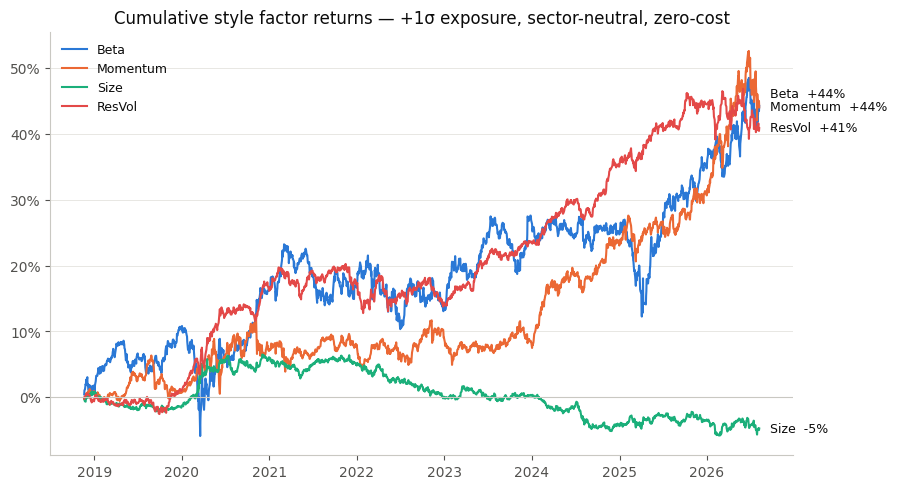

In [7]:
cumS = (1 + F_all[STYLES]).cumprod() - 1
colors = dict(zip(STYLES, [BLUE, ORANGE, AQUA, RED]))

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.subplots_adjust(right=0.80)
for n in STYLES:
    ax.plot(cumS.index, cumS[n], lw=1.5, color=colors[n], label=n)

lab = cumS.iloc[-1].sort_values()
gap = (cumS.values.max() - cumS.values.min()) / 28
for i in range(1, len(lab)):
    lab.iloc[i] = max(lab.iloc[i], lab.iloc[i - 1] + gap)
for n, y in lab.items():
    ax.annotate(f'{n}  {cumS[n].iloc[-1]:+.0%}', (cumS.index[-1], y),
                xytext=(8, 0), textcoords='offset points', va='center',
                fontsize=9, color=INK, clip_on=False)

ax.axhline(0, color=GRAY, lw=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.set_title('Cumulative style factor returns — +1σ exposure, sector-neutral, zero-cost')
plt.show()

## 7. Factor correlation — full 15×15

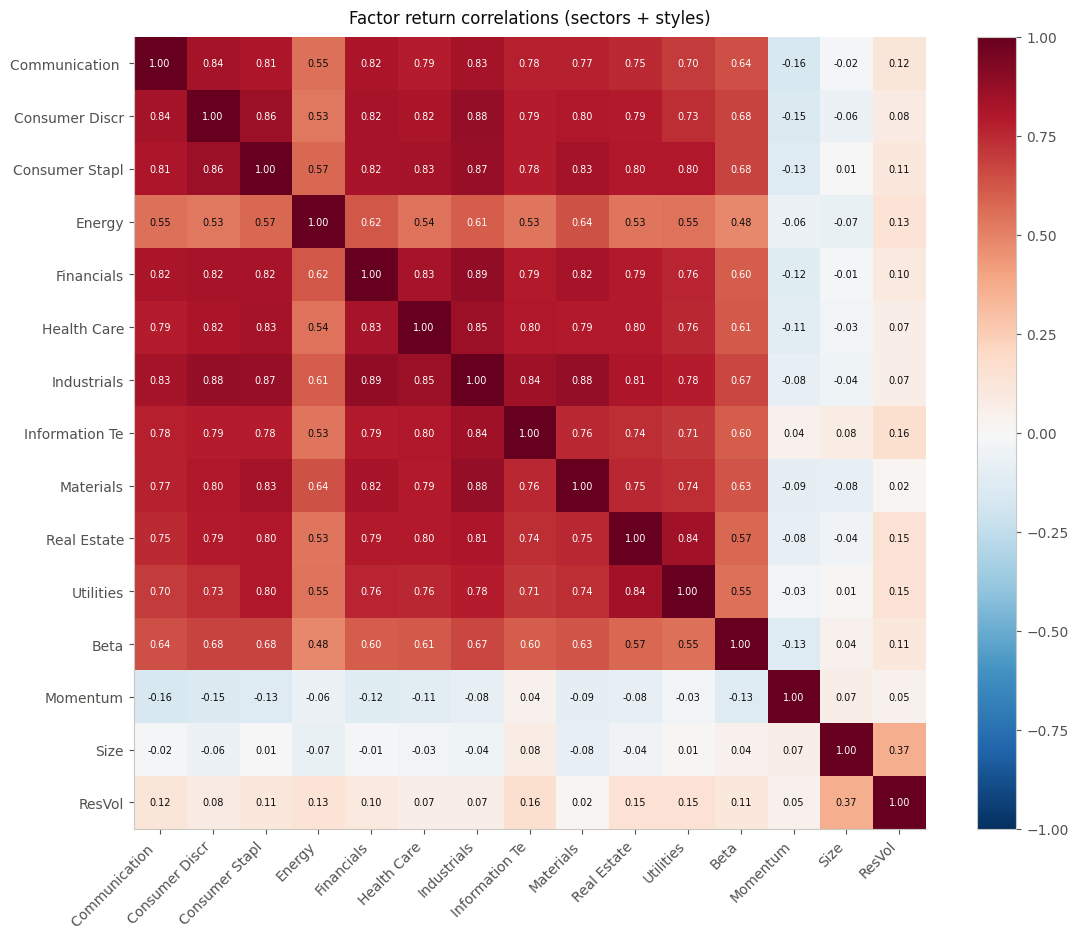

In [8]:
Fcorr = F_all.corr()
labels = [c[:14] for c in Fcorr.columns]

fig, ax = plt.subplots(figsize=(11.5, 9.5))
im = ax.imshow(Fcorr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels)), labels)
ax.set_title('Factor return correlations (sectors + styles)', pad=10)
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = Fcorr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 0.6 else INK)
plt.tight_layout()
plt.show()

## 8. Assembled risk model and portfolio decomposition

$\Sigma = B\,F\,B^\top + D$ with $B$ = the **latest day's** exposures (missing styles set
to 0 = average). One subtlety the numbers below make visible: the EW portfolio comes out
**exactly style-neutral**, because exposures are z-scored to an equal-weighted mean of 0 —
under this standardization the EW universe portfolio *is* the neutral portfolio. (Barra
standardizes to a cap-weighted mean instead, which makes the cap-weighted market neutral;
do that and an EW portfolio shows its familiar small-cap tilt.) Any other weighting — cap
weights, or an actual book — will show non-zero style exposures here.

In [9]:
Fcov_all = F_all.cov() * 252
spec_var = (E_all.var() * 252).reindex(rets.columns)
spec_var = spec_var.fillna(spec_var.median())

t_last = F_all.index[-1]
S_last = pd.concat([styles[n].loc[t_last].rename(n) for n in STYLES], axis=1) \
           .reindex(rets.columns).fillna(0)
B = np.column_stack([X.values, S_last.values])               # N x 15 latest exposures

Sigma = pd.DataFrame(B @ Fcov_all.values @ B.T + np.diag(spec_var),
                     index=rets.columns, columns=rets.columns)

w = pd.Series(1 / len(sec), index=sec.index)                 # equal-weight portfolio
bexp = pd.Series(B.T @ w.values, index=fac_cols)
var_fac  = bexp @ Fcov_all @ bexp
var_spec = (w**2 * spec_var).sum()
var_tot  = var_fac + var_spec

print(f'portfolio vol : {np.sqrt(var_tot):7.2%}')
print(f'  factor      : {np.sqrt(var_fac):7.2%}   ({var_fac / var_tot:5.1%} of variance)')
print(f'  specific    : {np.sqrt(var_spec):7.2%}   ({var_spec / var_tot:5.1%} of variance)')
print('\nstyle exposures of the EW portfolio (z-score units):')
print(bexp[STYLES].round(3).to_string())

contrib = (bexp * (Fcov_all @ bexp) / var_tot).sort_values(ascending=False)
contrib.round(3).to_frame('share of portfolio variance')

portfolio vol :  19.93%
  factor      :  19.89%   (99.6% of variance)
  specific    :   1.21%   ( 0.4% of variance)

style exposures of the EW portfolio (z-score units):
Beta        0.0
Momentum   -0.0
Size       -0.0
ResVol      0.0


,share of portfolio variance
Industrials,0.166
Financials,0.154
Information Technology,0.144
Health Care,0.112
Consumer Discretionary,0.097
Real Estate,0.064
Consumer Staples,0.062
Utilities,0.062
Materials,0.050
Communication Services,0.044


## 9. Save the model

Persist the fitted pieces as CSV + JSON (version-proof, unlike pickles) so any script or
notebook can analyze a portfolio without touching the raw data again:

```python
from risk_model import RiskModel
m = RiskModel.load('model')
m.report({'AAPL': 0.4, 'XOM': 0.3, 'JPM': 0.3})
```

See `portfolio_analysis.ipynb` for a worked example.

In [10]:
from risk_model import save_model

B_df = pd.DataFrame(B, index=rets.columns, columns=fac_cols)
save_model('model', exposures=B_df, factor_cov=Fcov_all, specific_var=spec_var,
           sectors=sec, factor_returns=F_all,
           meta={'fit_date': str(t_last.date()),
                 'window': [str(F_all.index.min().date()), str(F_all.index.max().date())],
                 'n_days': len(F_all), 'n_names': len(rets.columns),
                 'mean_xsec_r2': round(float(r2.mean()), 4),
                 'style_factors': STYLES, 'annualization': 252,
                 'notes': 'exposures z-scored to EW mean 0 / std 1, lagged 1 day; '
                          'Size = log 63d median dollar volume (size/liquidity proxy)'})
sorted(p.name for p in __import__('pathlib').Path('model').iterdir())

['exposures.csv',
 'factor_cov.csv',
 'factor_returns.csv',
 'meta.json',
 'sectors.csv',
 'specific_var.csv']

## 10. Upgrading the factor set

- **True SIZE** — needs shares outstanding. Quickest path: `pip install yfinance`, pull
  each name's current market cap, then back-fill history with the model's own return
  index: $\text{cap}_{i,t} = \text{cap}_{i,\text{now}} \cdot P_{i,t}/P_{i,\text{now}}$ where
  $P$ is the cumulated *cleaned* return index `(1 + rets).cumprod()` (split-safe, unlike
  raw close). Exposure = `xsec_z(np.log(cap))`. Caveat: today's share count applied
  backwards ignores buybacks/issuance.
- **Value (book-to-price), Earnings Yield, Growth, Leverage** — need fundamentals with
  point-in-time dates (Compustat, SimFin, or scraped filings). Lag statements ~3 months
  after fiscal period end to avoid lookahead; then the same `xsec_z` + regression handles
  them unchanged.
- **Estimation upgrades** when ready: √(cap)-weighted WLS in the daily regression,
  EWMA-weighted factor covariance with Newey-West adjustment, Bayesian shrinkage on
  specific variances — each is a drop-in change to one cell above.